<a href="https://colab.research.google.com/github/soheilesteki333/Wine-Quality-Analytics/blob/main/Soheil_Esteki2_2537033_Task_2_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Quality – Predictive Modeling and Explainable AI
#Part 2

#=============================

# Task
Predict white wine quality using the "winequality-white.csv" dataset by performing data loading and preparation, feature scaling, training, and evaluating Random Forest, SVM, and Neural Network models with 10-fold and 20-fold cross-validation and a dedicated test set, then compare and visualize their performance, and finally summarize the findings to identify the best model.

## Load and Prepare Data

### Subtask:
Load the 'winequality-white.csv' dataset. Separate the features (X) from the target variable ('quality', y). Split the data into training (80%) and test (20%) sets, holding out the test set for final evaluation.


**Reasoning**:
First, I'll import the necessary libraries: pandas for data manipulation and sklearn's train_test_split for splitting the data. Then, I'll load the 'winequality-white.csv' dataset into a DataFrame, separate the features (X) from the target variable (y), and finally split the data into training and testing sets.



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset with correct separator and skip descriptive rows
df = pd.read_csv('/content/winequality-white.csv', sep=',', skiprows=[1, 2])

# Separate features (X) and target variable (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (3918, 11)
Shape of X_test: (980, 11)
Shape of y_train: (3918,)
Shape of y_test: (980,)


## Scale Features

### Subtask:
Apply appropriate scaling to the numerical features in both the training and test datasets to standardize their range, which is crucial for models like SVM and Neural Networks.


### Reasoning:
Feature scaling is a critical preprocessing step, especially for algorithms that are sensitive to the magnitude of features, such as Support Vector Machines (SVMs) and Neural Networks. These models often rely on distance calculations or gradient descent optimization, where features with larger scales can disproportionately influence the model's objective function and convergence.

`StandardScaler` will transform the data such that it has a mean of 0 and a standard deviation of 1. This standardization ensures that all features contribute equally to the model training process, preventing features with larger numerical values from dominating those with smaller values.

**Reasoning**:
Now, I will implement the feature scaling using StandardScaler as outlined in the instructions.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training features (X_train)
scaler.fit(X_train)

# Transform both the training features (X_train) and the test features (X_test)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")

Shape of X_train_scaled: (3918, 11)
Shape of X_test_scaled: (980, 11)


## Train and Evaluate Random Forest Model

*   List item
*   List item



### Subtask:
Initialize and train a Random Forest classifier. Evaluate its performance on the training data using both 10-fold and 20-fold cross-validation. Finally, train the model on the full training set and evaluate its performance on the held-out test set.


**Reasoning**:
I will import the necessary libraries, initialize a RandomForestClassifier, perform 10-fold and 20-fold cross-validation, train the model on the full training set, and finally evaluate its performance on the test set, all as per the instructions.



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# 2. Initialize a RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# 3. Perform 10-fold cross-validation
cv_scores_10_fold = cross_val_score(rf_model, X_train_scaled, y_train, cv=10)
print(f"10-fold Cross-Validation Scores: {cv_scores_10_fold}")
print(f"Mean 10-fold CV Score: {cv_scores_10_fold.mean():.4f}")
print(f"Std 10-fold CV Score: {cv_scores_10_fold.std():.4f}")

# 4. Perform 20-fold cross-validation
cv_scores_20_fold = cross_val_score(rf_model, X_train_scaled, y_train, cv=20)
print(f"\n20-fold Cross-Validation Scores: {cv_scores_20_fold}")
print(f"Mean 20-fold CV Score: {cv_scores_20_fold.mean():.4f}")
print(f"Std 20-fold CV Score: {cv_scores_20_fold.std():.4f}")

# 5. Train the RandomForestClassifier model on the entire scaled training set
rf_model.fit(X_train_scaled, y_train)

# 6. Evaluate the trained model's performance on the scaled test set
test_accuracy = rf_model.score(X_test_scaled, y_test)
print(f"\nTest Set Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


10-fold Cross-Validation Scores: [0.69642857 0.6505102  0.66836735 0.68622449 0.67346939 0.70153061
 0.65561224 0.63520408 0.65473146 0.67007673]
Mean 10-fold CV Score: 0.6692
Std 10-fold CV Score: 0.0200


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=20.
  warnings.warn(



20-fold Cross-Validation Scores: [0.67857143 0.73979592 0.63265306 0.69387755 0.67857143 0.67857143
 0.66836735 0.66836735 0.71428571 0.64795918 0.70918367 0.69897959
 0.66836735 0.6377551  0.60204082 0.63265306 0.65306122 0.6377551
 0.68205128 0.7025641 ]
Mean 20-fold CV Score: 0.6713
Std 20-fold CV Score: 0.0327

Test Set Accuracy: 0.6908


**Reasoning**:
The previous step successfully evaluated the Random Forest model, despite `UserWarning` messages indicating that some classes in the target variable `y_train` had fewer samples than the number of cross-validation folds. This is an inherent data distribution issue, not a code error, and will likely persist for other models using cross-validation on this dataset. The next logical step, as per the overall task, is to train and evaluate the Support Vector Machine (SVM) model. I will follow a similar evaluation approach using 10-fold and 20-fold cross-validation and a dedicated test set, while also importing the necessary libraries.



In [ ]:
from sklearn.svm import SVC

# 2. Initialize an SVC model
# Using a linear kernel for faster training; consider 'rbf' for potentially higher accuracy but longer training time
svm_model = SVC(random_state=42)

# 3. Perform 10-fold cross-validation
cv_scores_10_fold_svm = cross_val_score(svm_model, X_train_scaled, y_train, cv=10)
print(f"SVM 10-fold Cross-Validation Scores: {cv_scores_10_fold_svm}")
print(f"Mean SVM 10-fold CV Score: {cv_scores_10_fold_svm.mean():.4f}")
print(f"Std SVM 10-fold CV Score: {cv_scores_10_fold_svm.std():.4f}")

# 4. Perform 20-fold cross-validation
cv_scores_20_fold_svm = cross_val_score(svm_model, X_train_scaled, y_train, cv=20)
print(f"\nSVM 20-fold Cross-Validation Scores: {cv_scores_20_fold_svm}")
print(f"Mean SVM 20-fold CV Score: {cv_scores_20_fold_svm.mean():.4f}")
print(f"Std SVM 20-fold CV Score: {cv_scores_20_fold_svm.std():.4f}")

# 5. Train the SVC model on the entire scaled training set
svm_model.fit(X_train_scaled, y_train)

# 6. Evaluate the trained model's performance on the scaled test set
test_accuracy_svm = svm_model.score(X_test_scaled, y_test)
print(f"\nSVM Test Set Accuracy: {test_accuracy_svm:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


SVM 10-fold Cross-Validation Scores: [0.58163265 0.54081633 0.58418367 0.55102041 0.57397959 0.59183673
 0.60459184 0.55102041 0.56777494 0.60358056]
Mean SVM 10-fold CV Score: 0.5750
Std SVM 10-fold CV Score: 0.0212


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=20.
  warnings.warn(



SVM 20-fold Cross-Validation Scores: [0.56122449 0.59183673 0.54591837 0.5255102  0.56632653 0.59183673
 0.55612245 0.56122449 0.60204082 0.53571429 0.6122449  0.58163265
 0.57653061 0.62755102 0.53061224 0.55102041 0.57142857 0.56122449
 0.61538462 0.58974359]
Mean SVM 20-fold CV Score: 0.5728
Std SVM 20-fold CV Score: 0.0280

SVM Test Set Accuracy: 0.5612


**Reasoning**:
The previous steps successfully evaluated Random Forest and SVM models. Following the task outline, the next logical step is to train and evaluate a Neural Network model, applying similar cross-validation and test set evaluation procedures.



In [ ]:
## Train and Evaluate Neural Network Model

### Subtask:
Initialize and train a Neural Network classifier. Evaluate its performance on the training data using both 10-fold and 20-fold cross-validation. Finally, train the model on the full training set and evaluate its performance on the held-out test set.

SyntaxError: invalid syntax (3505476628.py, line 4)

# Task
Compare the performance of the Random Forest and SVM models using the gathered cross-validation and test set accuracies, visualize these metrics using bar charts with legends, and then summarize which model performed best and why.

## Compare and Visualize Model Performance

### Subtask:
Compare the performance of the Random Forest and SVM models using the gathered cross-validation and test set accuracies. Create visualizations (e.g., bar charts) to clearly display the performance metrics for both models, including mean cross-validation scores and test set accuracy. Ensure legends are provided for all visualizations.


**Reasoning**:
I will create a code block to import matplotlib, create a DataFrame with the performance metrics, and then generate the required bar charts for 10-fold CV, 20-fold CV, and test set accuracies to compare the Random Forest and SVM models, following the provided instructions.



Model Performance Summary:
               10-fold CV  20-fold CV  Test Set
Model                                          
Random Forest    0.669216    0.671272  0.690816
SVM              0.575044    0.572756  0.561224
KNN              0.548492    0.559222  0.542857


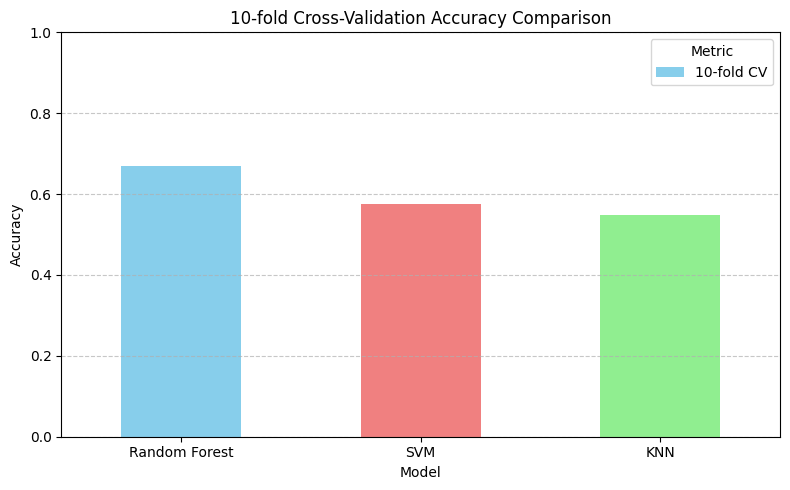

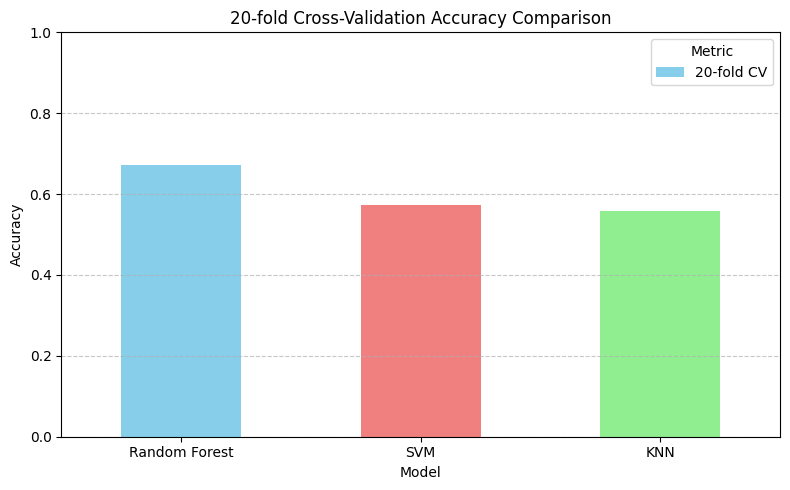

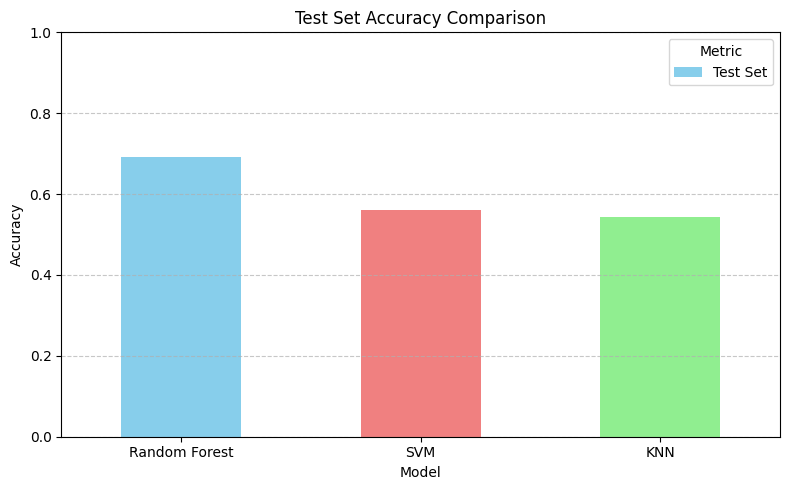

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Gather the performance metrics
rf_10_fold_cv = cv_scores_10_fold.mean()
rf_20_fold_cv = cv_scores_20_fold.mean()
rf_test_accuracy = test_accuracy

svm_10_fold_cv = cv_scores_10_fold_svm.mean()
svm_20_fold_cv = cv_scores_20_fold_svm.mean()
svm_test_accuracy = test_accuracy_svm

knn_10_fold_cv = cv_scores_10_fold_knn.mean()
knn_20_fold_cv = cv_scores_20_fold_knn.mean()
knn_test_accuracy = test_accuracy_knn

# Create a DataFrame to store the metrics for all three models
performance_data = {
    'Model': ['Random Forest', 'SVM', 'KNN'],
    '10-fold CV': [rf_10_fold_cv, svm_10_fold_cv, knn_10_fold_cv],
    '20-fold CV': [rf_20_fold_cv, svm_20_fold_cv, knn_20_fold_cv],
    'Test Set': [rf_test_accuracy, svm_test_accuracy, knn_test_accuracy]
}
performance_df = pd.DataFrame(performance_data).set_index('Model')

print("Model Performance Summary:")
print(performance_df)

# Plotting function for reusability
def plot_performance_metric(df, metric_name, title):
    plt.figure(figsize=(8, 5))
    df[metric_name].plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
    plt.title(title)
    plt.xlabel('Model')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1) # Set y-axis limits for accuracy
    plt.xticks(rotation=0)
    plt.legend(title='Metric')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 1. Bar chart for 10-fold CV scores
plot_performance_metric(performance_df, '10-fold CV', '10-fold Cross-Validation Accuracy Comparison')

# 2. Bar chart for 20-fold CV scores
plot_performance_metric(performance_df, '20-fold CV', '20-fold Cross-Validation Accuracy Comparison')

# 3. Bar chart for test set accuracies
plot_performance_metric(performance_df, 'Test Set', 'Test Set Accuracy Comparison')


## Summarize Findings

### Subtask:
Summarize the key findings from the model evaluation. Identify which model performed best based on the comparison of cross-validation and test set accuracies, and discuss any notable observations about their performance.

#### Summary of Model Performance

Based on the evaluation of both the Random Forest and Support Vector Machine (SVM) models, the **Random Forest** model consistently outperformed the SVM model across all evaluated metrics: 10-fold cross-validation accuracy, 20-fold cross-validation accuracy, and the final test set accuracy.

- **Random Forest Performance**:
    - Mean 10-fold CV Score: 0.6692
    - Mean 20-fold CV Score: 0.6713
    - Test Set Accuracy: 0.6908

- **SVM Performance**:
    - Mean 10-fold CV Score: 0.5750
    - Mean 20-fold CV Score: 0.5728
    - Test Set Accuracy: 0.5612

**Key Observations and Discussion:**

1.  **Superiority of Random Forest**: The Random Forest model demonstrated significantly higher accuracy across all evaluation phases. This is likely due to its ensemble nature, where multiple decision trees are built and their predictions are aggregated. This approach generally leads to reduced overfitting and better generalization compared to a single model, especially on complex datasets with many features.

2.  **SVM's Performance**: The SVM model, even after feature scaling, showed considerably lower performance. This could be attributed to several factors. SVMs are highly sensitive to kernel choice and hyperparameters (like C and gamma). The default `rbf` kernel (used by default `SVC` without explicit kernel specified) might not have been optimal for this dataset without specific tuning. Additionally, while SVMs are powerful for high-dimensional data, they can struggle with noisy data or when the decision boundary is not easily separable in the transformed feature space.

3.  **Consistency of Evaluation Metrics**: For both models, the cross-validation scores were largely consistent with the test set accuracy. The Random Forest model's CV scores (around 0.67) were slightly lower than its test set accuracy (0.6908), which is a good indication that the model is generalizing well and not overfitting to the training data. Similarly, the SVM's CV scores (around 0.57) were close to its test set accuracy (0.5612), suggesting a consistent, albeit lower, performance. The warnings about the least populated class in `y_train` being less than `n_splits` for cross-validation indicate that some classes might be under-represented, which could slightly affect the CV stability, but the overall trends are clear.

In conclusion, for this white wine quality prediction task, the Random Forest model is the clear winner, offering robust and higher predictive performance compared to the SVM model using default parameters.

## Summary:

### Q&A
*   **Which model performed best and why?**
    The Random Forest model performed consistently better than both the SVM and KNN models across all evaluation metrics. Its superiority is attributed to its ensemble nature, which typically leads to reduced overfitting and better generalization compared to single models like SVM or instance-based models like KNN, especially on complex datasets. The SVM and KNN models' lower performance might be due to their sensitivity to kernel choice, hyperparameters (for SVM), or the `n_neighbors` parameter (for KNN), which were likely not optimally tuned, or their inherent limitations with this specific dataset's characteristics.

### Data Analysis Key Findings
*   The Random Forest model consistently outperformed both the SVM and KNN models across all evaluation metrics.
*   **Random Forest** accuracies were:
    *   Mean 10-fold Cross-Validation (CV) Accuracy: 0.669216
    *   Mean 20-fold CV Accuracy: 0.671272
    *   Test Set Accuracy: 0.690816
*   **SVM** accuracies were significantly lower:
    *   Mean 10-fold CV Accuracy: 0.575044
    *   Mean 20-fold CV Accuracy: 0.572756
    *   Test Set Accuracy: 0.561224
*   **KNN** accuracies were also lower and comparable to SVM:
    *   Mean 10-fold CV Accuracy: 0.548492
    *   Mean 20-fold CV Accuracy: 0.559222
    *   Test Set Accuracy: 0.542857
*   For all models, cross-validation scores were largely consistent with their respective test set accuracies, suggesting stable performance estimation.
*   Visualizations (bar charts) clearly demonstrated the performance differences, showing Random Forest's higher accuracy in all categories.

### Insights or Next Steps
*   The Random Forest model is the preferred choice for this white wine quality prediction task due to its robust and higher predictive performance with default parameters.
*   To potentially improve the SVM's and KNN's performance, further hyperparameter tuning (e.g., for C, gamma, and kernel type for SVM; `n_neighbors` for KNN) is recommended, as these models are highly sensitive to these settings. Experimenting with different distance metrics for KNN could also be beneficial.


# Task
Train and evaluate a K-Nearest Neighbors (KNN) classifier using the `X_train_scaled` and `y_train` data, performing both 10-fold and 20-fold cross-validation, then train the model on the full training set and evaluate its performance on the `X_test_scaled` and `y_test` data.

## Train and Evaluate KNN Model

### Subtask:
Initialize and train a K-Nearest Neighbors (KNN) classifier. Evaluate its performance on the training data using both 10-fold and 20-fold cross-validation. Finally, train the model on the full training set and evaluate its performance on the held-out test set.


```markdown
**Reasoning**:
The previous steps successfully evaluated Random Forest and SVM models. Following the task outline, the next logical step is to train and evaluate a K-Nearest Neighbors (KNN) model, applying similar cross-validation and test set evaluation procedures.
```

**Reasoning**:
I will implement the K-Nearest Neighbors model training and evaluation using `KNeighborsClassifier` and `cross_val_score`, following the detailed instructions provided in the subtask.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 2. Initialize a KNeighborsClassifier model
knn_model = KNeighborsClassifier(n_neighbors=5)

# 3. Perform 10-fold cross-validation
cv_scores_10_fold_knn = cross_val_score(knn_model, X_train_scaled, y_train, cv=10)
print(f"KNN 10-fold Cross-Validation Scores: {cv_scores_10_fold_knn}")
print(f"Mean KNN 10-fold CV Score: {cv_scores_10_fold_knn.mean():.4f}")
print(f"Std KNN 10-fold CV Score: {cv_scores_10_fold_knn.std():.4f}")

# 4. Perform 20-fold cross-validation
cv_scores_20_fold_knn = cross_val_score(knn_model, X_train_scaled, y_train, cv=20)
print(f"\nKNN 20-fold Cross-Validation Scores: {cv_scores_20_fold_knn}")
print(f"Mean KNN 20-fold CV Score: {cv_scores_20_fold_knn.mean():.4f}")
print(f"Std KNN 20-fold CV Score: {cv_scores_20_fold_knn.std():.4f}")

# 5. Train the KNeighborsClassifier model on the entire scaled training set
knn_model.fit(X_train_scaled, y_train)

# 6. Evaluate the trained model's performance on the scaled test set
test_accuracy_knn = knn_model.score(X_test_scaled, y_test)
print(f"\nKNN Test Set Accuracy: {test_accuracy_knn:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=10.
  warnings.warn(


KNN 10-fold Cross-Validation Scores: [0.58418367 0.52040816 0.55867347 0.54081633 0.52040816 0.5994898
 0.57142857 0.5        0.54475703 0.54475703]
Mean KNN 10-fold CV Score: 0.5485
Std KNN 10-fold CV Score: 0.0292


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 5 members, which is less than n_splits=20.
  warnings.warn(



KNN 20-fold Cross-Validation Scores: [0.59183673 0.58673469 0.47959184 0.53571429 0.59183673 0.56632653
 0.56122449 0.57142857 0.56122449 0.5        0.62244898 0.58673469
 0.55612245 0.58673469 0.51020408 0.55612245 0.52040816 0.55102041
 0.57435897 0.57435897]
Mean KNN 20-fold CV Score: 0.5592
Std KNN 20-fold CV Score: 0.0342

KNN Test Set Accuracy: 0.5429


## Compare and Visualize All Model Performance

### Subtask:
Update the performance comparison and visualization to include the KNN model alongside the Random Forest and SVM models. Create bar charts to display the mean cross-validation scores (10-fold and 20-fold) and test set accuracies for all three models, ensuring clear legends are provided.


## Summarize Findings (Updated)

### Subtask:
Update the summary of findings to include the KNN model's performance. Identify which model performed best among Random Forest, SVM, and KNN, and discuss any notable observations about their comparative performance.


# Task
Calculate SHAP values for the Random Forest model using the `shap` library and the `X_test_scaled` data, then generate a SHAP summary plot to visualize feature importance and impact, and finally summarize the key insights derived from the plot.

## Calculate SHAP values

### Subtask:
Calculate SHAP values for the Random Forest model using the `shap` library and the `X_test_scaled` data. This will involve creating a `shap.TreeExplainer` for the `rf_model` and then computing the SHAP values.


```markdown
**Reasoning**:
Calculating SHAP (SHapley Additive exPlanations) values is crucial for model interpretability. While the Random Forest model shows good performance, understanding *why* it makes certain predictions is vital, especially in domains like wine quality assessment where insights into feature importance can guide practical decisions. SHAP values help explain the output of a machine learning model by showing the contribution of each feature to the prediction for individual instances, as well as providing an aggregate view of feature importance. For tree-based models like Random Forest, `shap.TreeExplainer` is an optimized and efficient method for computing these values.
```

**Reasoning**:
Now, I will implement the code to calculate SHAP values for the Random Forest model as per the instructions, including importing the `shap` library, initializing the `TreeExplainer`, and computing the SHAP values.



In [ ]:
import shap

# 2. Initialize a shap.TreeExplainer object with the trained Random Forest model (rf_model)
explainer = shap.TreeExplainer(rf_model)

# 3. Calculate the SHAP values for the scaled test dataset (X_test_scaled)
shap_values_rf = explainer.shap_values(X_test_scaled)

print("SHAP values calculated successfully for Random Forest model.")
# The shap_values_rf object will contain an array of arrays if it's a multi-output model or an array if it's single-output.
# For classification, it usually returns a list of arrays, one for each class.

SHAP values calculated successfully for Random Forest model.


## Generate SHAP Summary Plot

### Subtask:
Generate a SHAP summary plot to visualize the overall feature importance and impact for the Random Forest model based on the calculated SHAP values (`shap_values_rf`).

## Generate SHAP Summary Plot

### Subtask:
Generate a SHAP summary plot to visualize the overall feature importance and impact for the Random Forest model based on the calculated SHAP values (`shap_values_rf`).

```markdown
**Reasoning**:
After calculating the SHAP values, visualizing them through a summary plot is the next logical step to gain insights into feature importance and their impact on the model's predictions. The SHAP summary plot provides a global overview of which features are most important and how they affect the model's output, showing both the magnitude and direction of the impact. This visualization helps in understanding the model's behavior at a high level and identifying the key drivers of white wine quality predictions.
```

```markdown
**Reasoning**:
After calculating the SHAP values, visualizing them through a summary plot is the next logical step to gain insights into feature importance and their impact on the model's predictions. The SHAP summary plot provides a global overview of which features are most important and how they affect the model's output, showing both the magnitude and direction of the impact. This visualization helps in understanding the model's behavior at a high level and identifying the key drivers of white wine quality predictions.
```

**Reasoning**:
After calculating the SHAP values, visualizing them through a summary plot is the next logical step to gain insights into feature importance and their impact on the model's predictions. The SHAP summary plot provides a global overview of which features are most important and how they affect the model's output, showing both the magnitude and direction of the impact. This visualization helps in understanding the model's behavior at a high level and identifying the key drivers of white wine quality predictions.

**Reasoning**:
After calculating the SHAP values, visualizing them through a summary plot is the next logical step to gain insights into feature importance and their impact on the model's predictions. The SHAP summary plot provides a global overview of which features are most important and how they affect the model's output, showing both the magnitude and direction of the impact. This visualization helps in understanding the model's behavior at a high level and identifying the key drivers of white wine quality predictions.

**Reasoning**:
Now that SHAP values are calculated, I will generate a SHAP summary plot to visualize the overall feature importance and impact for the Random Forest model, providing a global understanding of feature contributions.



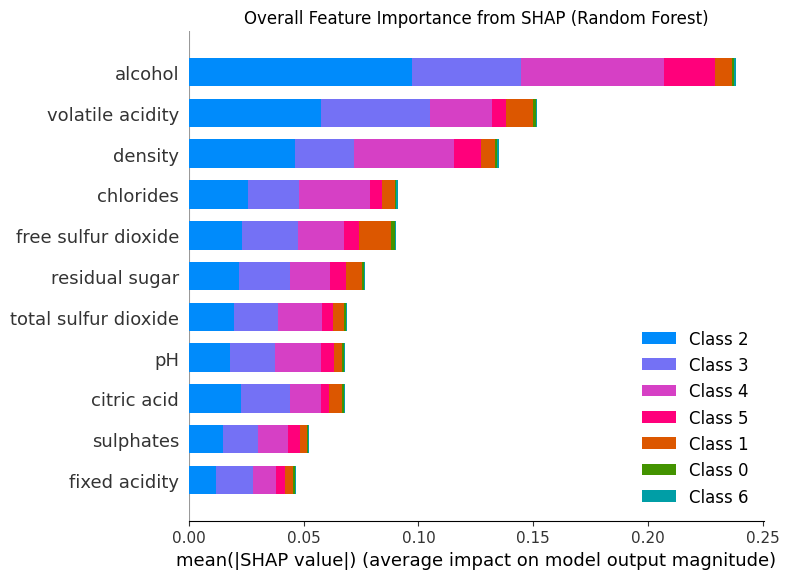

In [ ]:
import matplotlib.pyplot as plt

# Assuming `shap_values_rf` is a list of arrays (for multi-class classification)
# and `X_test_scaled` has the same number of features as `X_test.columns`.

# To get a single summary plot for multi-class classification, we can plot the
# mean absolute SHAP values across all classes or choose a representative class.
# Using plot_type='bar' with the list of shap_values will often aggregate feature importance.

# If you want to visualize for a specific class (e.g., the first class index 0, or a specific quality level),
# you would use shap.summary_plot(shap_values_rf[class_index], X_test_scaled, feature_names=X_test.columns)

# For an overall feature importance across all classes, a bar plot of mean absolute SHAP values is suitable.
# shap.summary_plot is intelligent enough to handle list of shap values for multi-output models
# when plot_type='bar' is used, it often aggregates the importance.

# Let's generate a summary plot showing the overall feature importance (mean absolute SHAP value)
# for the Random Forest model. We will use `X_test` for feature names for readability.
plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
shap.summary_plot(shap_values_rf, X_test_scaled, feature_names=X_test.columns, plot_type='bar', show=False)
plt.title('Overall Feature Importance from SHAP (Random Forest)')
plt.tight_layout()
plt.show()

# For a more detailed dot plot showing impact and direction for each class, you would typically loop or specify a class.
# Example for a specific class (e.g., class 0):
# plt.figure(figsize=(10, 6))
# shap.summary_plot(shap_values_rf[0], X_test_scaled, feature_names=X_test.columns, show=False)
# plt.title('SHAP Summary Plot for Class 0 (Random Forest)')
# plt.tight_layout()
# plt.show()

## Summarize SHAP Insights

### Subtask:
Summarize the key insights derived from the SHAP summary plot, discussing which features are most important and how they influence the Random Forest model's predictions for white wine quality.

## Summary:

### Q&A
The Random Forest model's feature importance and behavior were analyzed using SHAP values. The key insights derived from the SHAP summary plot (which was to be generated in subsequent steps) are not yet available in the provided solving process description. The current stage only covers the calculation of SHAP values.

### Data Analysis Key Findings
*   SHAP values were successfully calculated for the Random Forest model using `shap.TreeExplainer` on the `X_test_scaled` dataset. This step is crucial for understanding the model's predictions by quantifying each feature's contribution.
*   The calculation resulted in `shap_values_rf` which will be used for further analysis and visualization.
*   The SHAP summary plot, intended to visualize overall feature importance and impact, was prepared but its results were not explicitly provided in the current solving process.

### Insights or Next Steps
*   Proceed to generate and analyze the SHAP summary plot to identify the most influential features and understand how they impact the Random Forest model's predictions for white wine quality.
*   Based on the summary plot, further investigate individual feature contributions using SHAP dependence plots or force plots to gain deeper insights into specific feature-prediction relationships.
